In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

In [2]:
plt.rcParams['font.family']= 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Graphik' 

In [3]:
#%matplotlib ipympl

In [4]:
starsystems = pd.read_csv('exoplanet_archive_2026_06_22.csv', skiprows=28)

In [5]:
ras = starsystems['ra']
decs = starsystems['dec']
distance = starsystems['sy_dist']
temps = starsystems['st_teff']

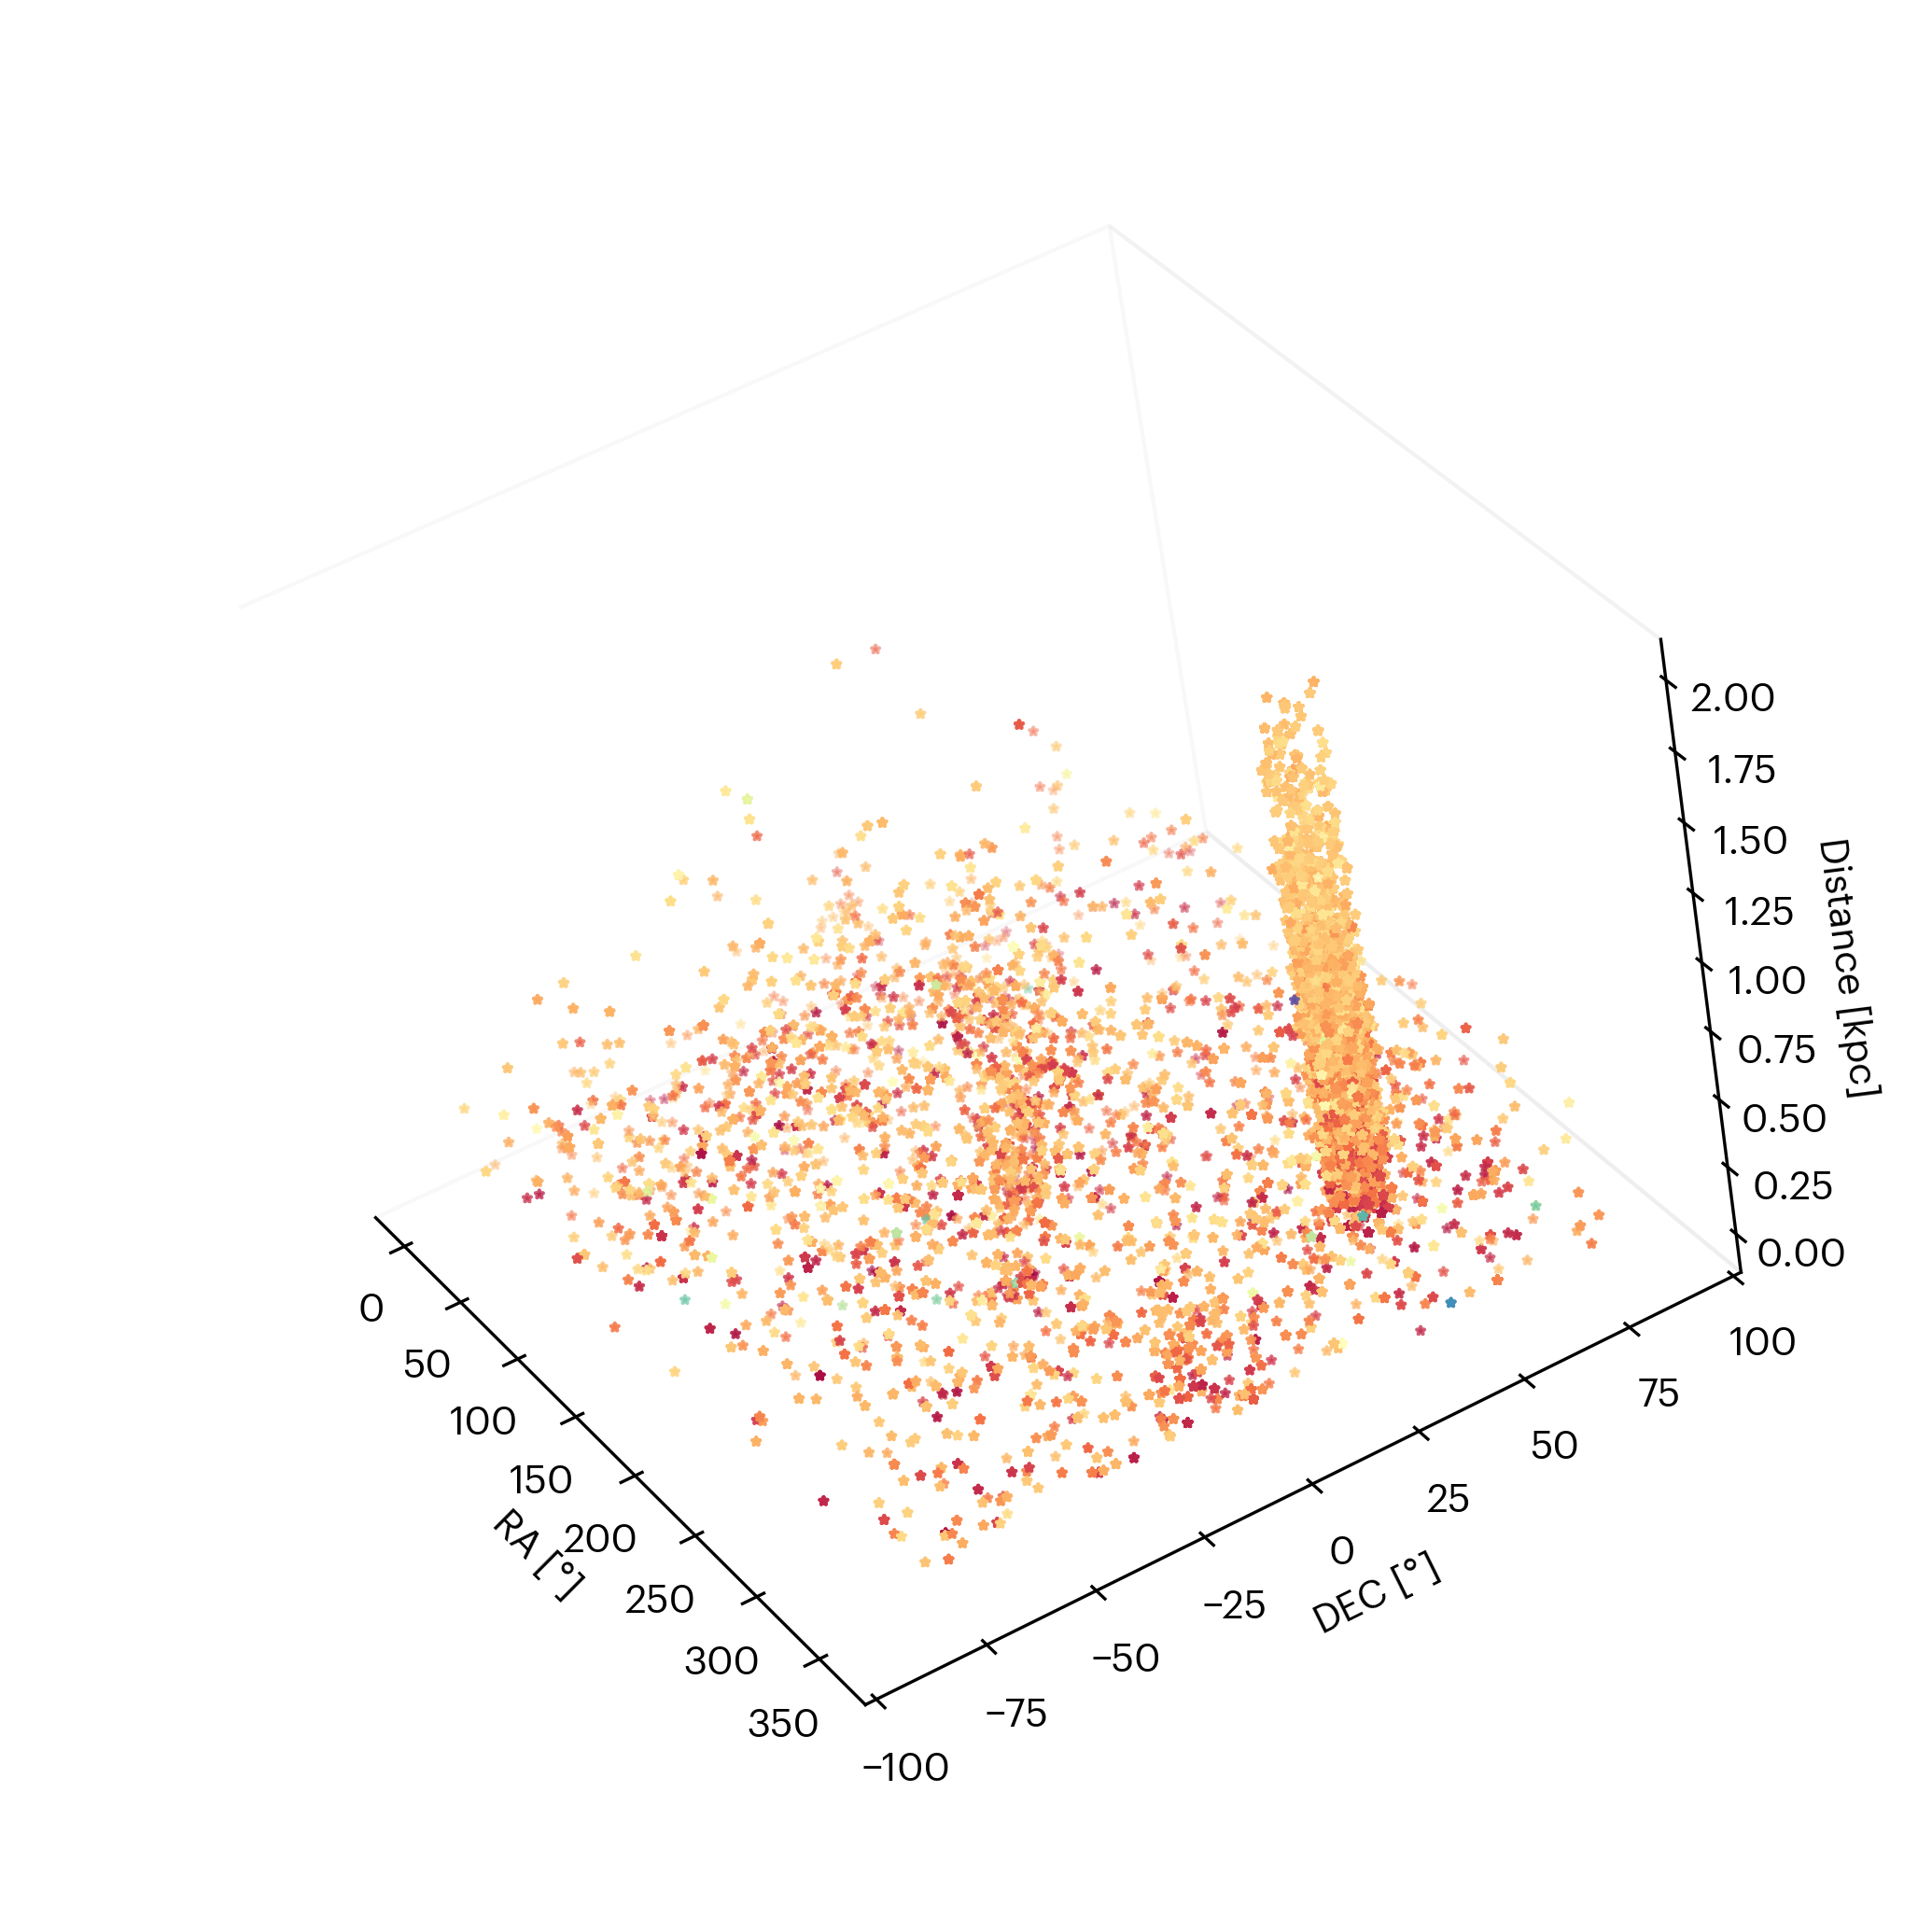

In [8]:
extreme_dist = distance < 2000
nan_temp = ~np.isnan(temps)
master_mask = nan_temp & extreme_dist
cmap = mpl.colormaps['Spectral']
norm = plt.Normalize(vmin= np.min(temps[master_mask]/temps[master_mask].max()),
                     vmax=0.4)
fig = plt.figure(dpi=300, figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.scatter(ras[master_mask], decs[master_mask], distance[master_mask]/1e3,  s=4, c = temps[master_mask]/temps[master_mask].max(),
           cmap = 'Spectral', norm = norm, marker = '*')
ax.set_xlabel(r'RA [$\degree$]')
ax.set_ylabel(r'DEC [$\degree$]')
ax.set_zlabel('Distance [kpc]')
ax.view_init(elev=35., azim=-25, roll=10)
ax.grid(False)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_box_aspect(None, zoom=0.85)
fig.tight_layout()

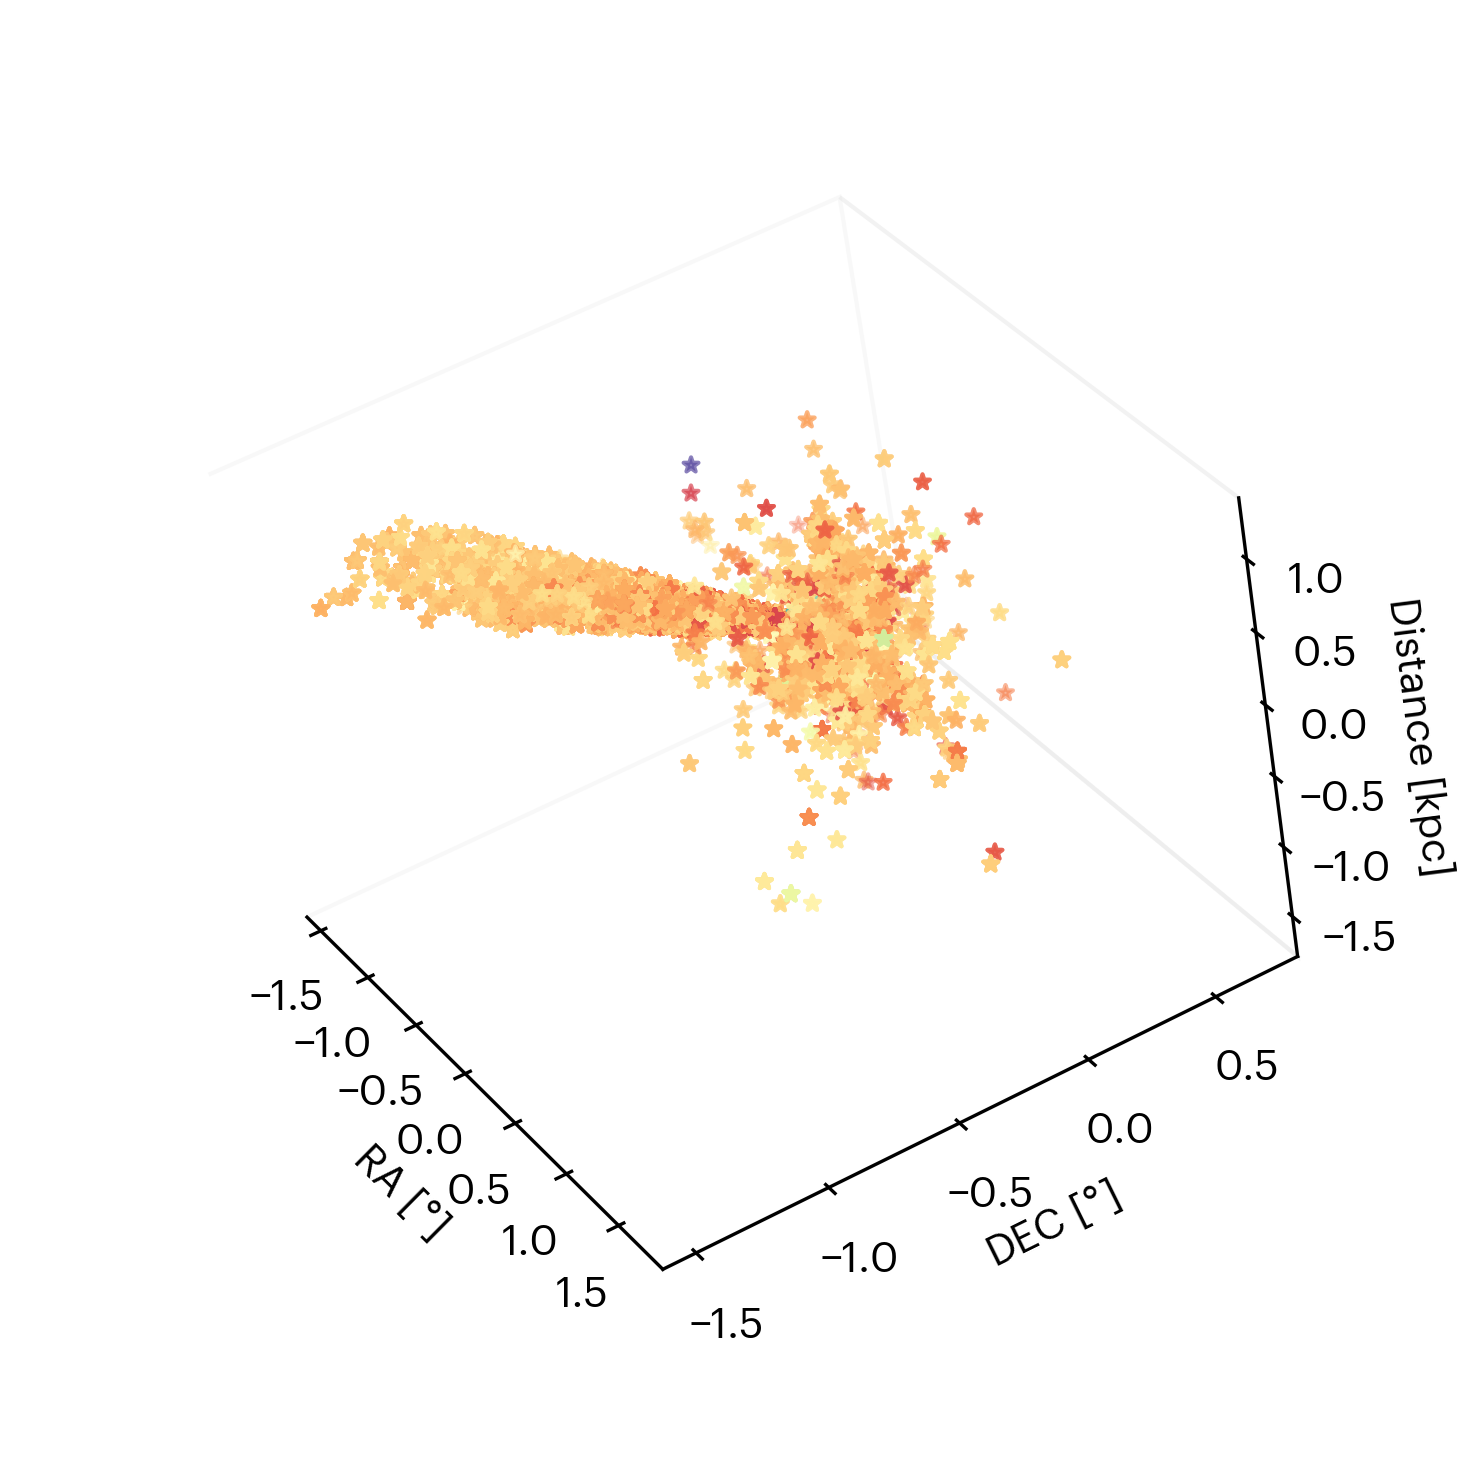

In [11]:
DECS, RAS = np.deg2rad(decs[master_mask]), np.deg2rad(ras[master_mask])
x = distance[master_mask]/1e3 * np.sin(RAS) * np.cos(DECS)
y = distance[master_mask]/1e3 * np.sin(RAS) * np.sin(DECS)
z = distance[master_mask]/1e3 * np.cos(RAS)

fig = plt.figure(dpi=300, figsize=(5,5))
ax = fig.add_subplot(projection='3d')
ax.scatter(x, y,z, 
            s=14, c = temps[master_mask]/temps[master_mask].max(),
           cmap = 'Spectral', norm = norm, marker = '*')

ax.set_xlabel(r'RA [$\degree$]')
ax.set_ylabel(r'DEC [$\degree$]')
ax.set_zlabel('Distance [kpc]')
ax.view_init(elev=35., azim=-25, roll=10)
ax.grid(False)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
#ax.axis('off')
ax.set_box_aspect(None, zoom=0.82)
fig.tight_layout()
plt.show()